# Machine Learning Foundations: Logistic Regression & Regularization

**Summary**
This notebook implements logistic regression from scratch to solve binary classification problems. It covers both standard and regularized logistic regression, demonstrating how to handle linearly and non-linearly separable datasets.

**Key Takeaways:**

1. **Sigmoid Function**: The logistic function $g(z) = \frac{1}{1+e^{-z}}$ maps any real-valued number to $(0, 1)$, making it ideal for outputting probabilities.
2. **Log-Loss Cost**: Unlike MSE used in linear regression, logistic regression uses log-loss (binary cross-entropy) to avoid non-convexity: $J = -\frac{1}{m}\sum[y\log(f) + (1-y)\log(1-f)]$.
3. **Same Gradient Descent Framework**: The gradient update loop is structurally identical to linear regression — only the prediction function $f_{w,b}$ changes.
4. **Decision Boundary**: The model predicts class 1 when $\sigma(w \cdot x + b) \geq 0.5$, i.e., when $w \cdot x + b \geq 0$ — this is the decision boundary.
5. **Regularization**: Adding an L2 penalty $\frac{\lambda}{2m}\sum w_j^2$ to the cost prevents overfitting by discouraging large weights (bias $b$ is not regularized).
6. **Feature Mapping**: Non-linearly separable data can be handled by engineering polynomial features before applying logistic regression.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import copy

np.set_printoptions(precision=2)

## Part 1: Logistic Regression — Binary Classification

### 1.1 Dataset

We'll use a synthetic university admissions dataset: given two exam scores, predict whether a student was admitted (1) or not (0).

In [2]:
# Generate synthetic admissions dataset (linearly separable)
rng = np.random.default_rng(42)
m = 100

# Admitted students: higher scores centered around (65, 65)
X_admitted = rng.standard_normal((60, 2)) * 10 + np.array([65, 65])
y_admitted = np.ones(60)

# Not admitted: lower scores centered around (45, 45)
X_rejected = rng.standard_normal((40, 2)) * 10 + np.array([45, 45])
y_rejected = np.zeros(40)

X_train = np.vstack([X_admitted, X_rejected])
y_train = np.concatenate([y_admitted, y_rejected])

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("First 5 examples:\n", X_train[:5])
print("First 5 labels:", y_train[:5])

X_train shape: (100, 2)
y_train shape: (100,)
First 5 examples:
 [[68.05 54.6 ]
 [72.5  74.41]
 [45.49 51.98]
 [66.28 61.84]
 [64.83 56.47]]
First 5 labels: [1. 1. 1. 1. 1.]


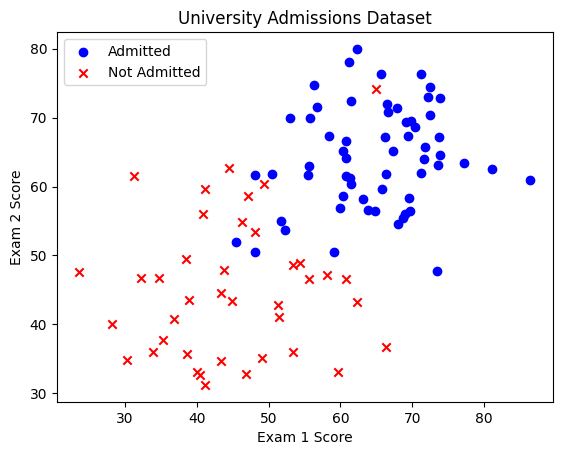

In [3]:
# Visualize the dataset
admitted = X_train[y_train == 1]
rejected = X_train[y_train == 0]

plt.scatter(admitted[:, 0], admitted[:, 1], marker='o', c='blue', label='Admitted')
plt.scatter(rejected[:, 0], rejected[:, 1], marker='x', c='red', label='Not Admitted')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.title('University Admissions Dataset')
plt.legend()
plt.show()

### 1.2 Sigmoid Function

The sigmoid function is the core of logistic regression. It maps any real number $z$ to a value between 0 and 1:

$$g(z) = \frac{1}{1 + e^{-z}}$$

The model output $f_{w,b}(x) = g(w \cdot x + b)$ is interpreted as the **probability that $y = 1$**.

In [4]:
def sigmoid(z):
    """
    Compute the sigmoid of z.

    Args:
        z (scalar or ndarray): Any real-valued scalar or array.

    Returns:
        g (scalar or ndarray): sigmoid(z), same shape as input.
    """
    g = 1 / (1 + np.exp(-z))
    return g


# Quick verification
print(f"sigmoid(0)   = {sigmoid(0)}")          # Expected: 0.5
print(f"sigmoid(100) = {sigmoid(100):.4f}")    # Expected: ~1.0
print(f"sigmoid(-100)= {sigmoid(-100):.4f}")   # Expected: ~0.0
print(f"sigmoid([-1, 0, 1, 2]) = {sigmoid(np.array([-1, 0, 1, 2]))}")

sigmoid(0)   = 0.5
sigmoid(100) = 1.0000
sigmoid(-100)= 0.0000
sigmoid([-1, 0, 1, 2]) = [0.27 0.5  0.73 0.88]


### 1.3 Cost Function (Log-Loss / Binary Cross-Entropy)

We can't use MSE for logistic regression — the non-linear sigmoid would make the cost non-convex with many local minima. Instead we use **log-loss**:

$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log\left(f_{w,b}(x^{(i)})\right) + (1 - y^{(i)}) \log\left(1 - f_{w,b}(x^{(i)})\right) \right]$$

- When $y=1$: cost = $-\log(f)$ — penalizes predictions far below 1
- When $y=0$: cost = $-\log(1-f)$ — penalizes predictions far above 0

In [5]:
def compute_cost(X, y, w, b, *argv):
    """
    Computes the logistic regression cost (log-loss).

    Args:
        X (ndarray (m,n)): Data, m examples by n features
        y (ndarray (m,)):  Target labels (0 or 1)
        w (ndarray (n,)):  Model weights
        b (scalar):        Model bias
        *argv:             Unused; allows compatibility with regularized version

    Returns:
        total_cost (scalar): Log-loss over all examples
    """
    m, n = X.shape
    cost = 0.0
    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_wb_i = sigmoid(z_i)
        cost += -y[i] * np.log(f_wb_i) - (1 - y[i]) * np.log(1 - f_wb_i)
    total_cost = cost / m
    return total_cost


# Verify: cost with all-zero params should be ~0.693 (log(2))
m, n = X_train.shape
initial_w = np.zeros(n)
initial_b = 0.0
cost_zero = compute_cost(X_train, y_train, initial_w, initial_b)
print(f"Cost at zero init (expected ~0.693): {cost_zero:.3f}")

Cost at zero init (expected ~0.693): 0.693


### 1.4 Gradient for Logistic Regression

Interestingly, the gradient formulas look identical to linear regression:

$$\frac{\partial J}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} \left(f_{w,b}(x^{(i)}) - y^{(i)}\right) x_j^{(i)}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left(f_{w,b}(x^{(i)}) - y^{(i)}\right)$$

The difference is hidden inside $f_{w,b}$ — it uses sigmoid instead of the linear function.

In [6]:
def compute_gradient(X, y, w, b, *argv):
    """
    Computes the gradient for logistic regression.

    Args:
        X (ndarray (m,n)): Data, m examples by n features
        y (ndarray (m,)):  Target labels
        w (ndarray (n,)):  Model weights
        b (scalar):        Model bias
        *argv:             Unused; for compatibility with regularized version

    Returns:
        dj_db (scalar):    Gradient w.r.t. bias b
        dj_dw (ndarray (n,)): Gradient w.r.t. weights w
    """
    m, n = X.shape
    dj_dw = np.zeros(w.shape)
    dj_db = 0.0

    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i], w) + b)
        err = f_wb_i - y[i]
        for j in range(n):
            dj_dw[j] += err * X[i, j]
        dj_db += err

    dj_dw /= m
    dj_db /= m

    return dj_db, dj_dw


# Verify gradients at zero init
dj_db, dj_dw = compute_gradient(X_train, y_train, initial_w, initial_b)
print(f"dj_db at zero init: {dj_db:.4f}")
print(f"dj_dw at zero init: {dj_dw}")

dj_db at zero init: -0.1000
dj_dw at zero init: [-10.38 -10.2 ]


### 1.5 Gradient Descent

Reusing the same gradient descent framework from previous notebooks — the cost and gradient functions are passed in as arguments, keeping it generic.

In [7]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_=0):
    """
    Performs batch gradient descent to learn w and b.

    Args:
        X (ndarray (m,n)):    Input features
        y (ndarray (m,)):     Target labels
        w_in (ndarray (n,)):  Initial weights
        b_in (scalar):        Initial bias
        cost_function:        Function to compute cost
        gradient_function:    Function to compute gradients
        alpha (float):        Learning rate
        num_iters (int):      Number of iterations
        lambda_ (float):      Regularization parameter (0 = no regularization)

    Returns:
        w (ndarray (n,)): Optimized weights
        b (scalar):       Optimized bias
        j_history (list): Cost at each iteration
    """
    w = copy.deepcopy(w_in)
    b = b_in
    j_history = []

    for i in range(num_iters):
        dj_db, dj_dw = gradient_function(X, y, w, b, lambda_)
        w -= alpha * dj_dw
        b -= alpha * dj_db

        cost = cost_function(X, y, w, b, lambda_)
        j_history.append(cost)

        if i % math.ceil(num_iters / 10) == 0 or i == num_iters - 1:
            print(f"Iteration {i:5}: Cost {j_history[-1]:.4f}")

    return w, b, j_history

In [8]:
# Train logistic regression on the admissions dataset
rng = np.random.default_rng(1)
initial_w = 0.01 * (rng.random(n) - 0.5)
initial_b = -8.0

iterations = 10000
alpha = 0.001

w, b, j_history = gradient_descent(
    X_train, y_train, initial_w, initial_b,
    compute_cost, compute_gradient, alpha, iterations
)

print(f"\nFinal w: {w}, b: {b:.4f}")

Iteration     0: Cost 1.6865
Iteration  1000: Cost 0.2858
Iteration  2000: Cost 0.2855
Iteration  3000: Cost 0.2851
Iteration  4000: Cost 0.2848
Iteration  5000: Cost 0.2844
Iteration  6000: Cost 0.2841
Iteration  7000: Cost 0.2838
Iteration  8000: Cost 0.2834
Iteration  9000: Cost 0.2831
Iteration  9999: Cost 0.2828

Final w: [0.08 0.08], b: -8.1839


### 1.6 Decision Boundary

The decision boundary is the line where $w \cdot x + b = 0$, i.e., the model is 50% confident. For 2 features:

$$x_2 = -\frac{w_0 x_1 + b}{w_1}$$

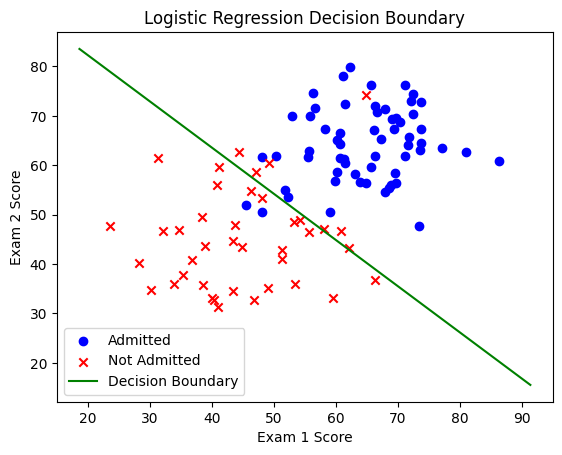

In [9]:
# Plot data + decision boundary
admitted = X_train[y_train == 1]
rejected = X_train[y_train == 0]

plt.scatter(admitted[:, 0], admitted[:, 1], marker='o', c='blue', label='Admitted')
plt.scatter(rejected[:, 0], rejected[:, 1], marker='x', c='red', label='Not Admitted')

# Decision boundary: w[0]*x1 + w[1]*x2 + b = 0  =>  x2 = -(w[0]*x1 + b) / w[1]
x1_vals = np.linspace(X_train[:, 0].min() - 5, X_train[:, 0].max() + 5, 100)
x2_vals = -(w[0] * x1_vals + b) / w[1]

plt.plot(x1_vals, x2_vals, 'g-', label='Decision Boundary')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.show()

### 1.7 Prediction & Accuracy

Threshold: predict class 1 if $f_{w,b}(x) \geq 0.5$, else class 0.

In [10]:
def predict(X, w, b):
    """
    Predict binary labels using learned logistic regression parameters.

    Args:
        X (ndarray (m,n)): Data, m examples by n features
        w (ndarray (n,)):  Model weights
        b (scalar):        Model bias

    Returns:
        p (ndarray (m,)): Predictions — 0 or 1
    """
    m, n = X.shape
    p = np.zeros(m)
    for i in range(m):
        f_wb = sigmoid(np.dot(X[i], w) + b)
        p[i] = 1 if f_wb >= 0.5 else 0
    return p


# Evaluate on training set
p = predict(X_train, w, b)
accuracy = np.mean(p == y_train) * 100
print(f"Train Accuracy: {accuracy:.2f}%")

Train Accuracy: 91.00%


---

## Part 2: Regularized Logistic Regression

When data is **not linearly separable**, we can engineer polynomial features to create a non-linear boundary — but this risks overfitting. **Regularization** controls this by penalizing large weights.

### 2.1 Dataset

This dataset represents microchip quality tests (two test scores) and whether the chip passed or failed. The boundary is non-linear — no straight line can separate the classes.

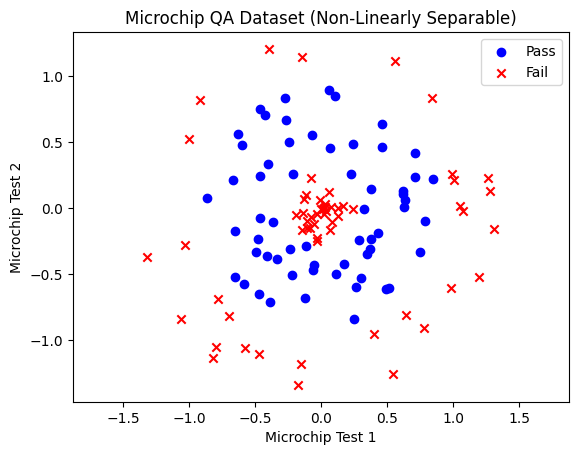

In [11]:
# Generate synthetic microchip dataset (non-linearly separable — circular boundary)
rng = np.random.default_rng(0)
m2 = 120
theta = rng.uniform(0, 2 * np.pi, m2)
r_pass = rng.uniform(0.3, 0.9, m2 // 2)
r_fail_inner = rng.uniform(0.0, 0.25, m2 // 4)
r_fail_outer = rng.uniform(1.0, 1.4, m2 // 4)

# Passed chips: ring-shaped cluster
X2_pass = np.column_stack([r_pass * np.cos(theta[:m2//2]), r_pass * np.sin(theta[:m2//2])])
y2_pass = np.ones(m2 // 2)

# Failed chips: inner and outer clusters
X2_fail = np.vstack([
    np.column_stack([r_fail_inner * np.cos(theta[:m2//4]), r_fail_inner * np.sin(theta[:m2//4])]),
    np.column_stack([r_fail_outer * np.cos(theta[:m2//4]), r_fail_outer * np.sin(theta[:m2//4])])
])
y2_fail = np.zeros(m2 // 2)

X2_train = np.vstack([X2_pass, X2_fail])
y2_train = np.concatenate([y2_pass, y2_fail])

# Visualize
passed = X2_train[y2_train == 1]
failed = X2_train[y2_train == 0]

plt.scatter(passed[:, 0], passed[:, 1], marker='o', c='blue', label='Pass')
plt.scatter(failed[:, 0], failed[:, 1], marker='x', c='red', label='Fail')
plt.xlabel('Microchip Test 1')
plt.ylabel('Microchip Test 2')
plt.title('Microchip QA Dataset (Non-Linearly Separable)')
plt.legend()
plt.axis('equal')
plt.show()

### 2.2 Feature Mapping

To fit a non-linear boundary, we map the two original features $(x_1, x_2)$ into all polynomial terms up to degree 6:

$$[1, x_1, x_2, x_1^2, x_1 x_2, x_2^2, x_1^3, \ldots, x_2^6]$$

This gives 28 features and allows the logistic regression to learn a complex boundary — at the cost of potential overfitting.

In [12]:
def map_feature(x1, x2, degree=6):
    """
    Maps two features into polynomial features up to the given degree.

    Args:
        x1 (ndarray (m,)): Feature 1
        x2 (ndarray (m,)): Feature 2
        degree (int):       Max polynomial degree

    Returns:
        out (ndarray (m, num_features)): Mapped feature matrix
    """
    out = [np.ones(len(x1))]
    for i in range(1, degree + 1):
        for j in range(i + 1):
            out.append((x1 ** (i - j)) * (x2 ** j))
    return np.column_stack(out)


X2_mapped = map_feature(X2_train[:, 0], X2_train[:, 1])
print(f"Original shape: {X2_train.shape}")
print(f"After feature mapping (degree 6): {X2_mapped.shape}")

Original shape: (120, 2)
After feature mapping (degree 6): (120, 28)


### 2.3 Regularized Cost Function

Add an L2 penalty on weights (not bias) to prevent large coefficients:

$$J_{reg}(w, b) = J(w, b) + \frac{\lambda}{2m} \sum_{j=1}^{n} w_j^2$$

- Small $\lambda$: minimal regularization, model can overfit
- Large $\lambda$: heavy regularization, model may underfit

In [13]:
def compute_cost_reg(X, y, w, b, lambda_=1):
    """
    Computes regularized logistic regression cost.

    Args:
        X (ndarray (m,n)): Data
        y (ndarray (m,)):  Labels
        w (ndarray (n,)):  Weights
        b (scalar):        Bias
        lambda_ (float):   Regularization strength

    Returns:
        total_cost (scalar): Regularized cost
    """
    m, n = X.shape
    cost_without_reg = compute_cost(X, y, w, b)
    reg_cost = (lambda_ / (2 * m)) * np.sum(w ** 2)
    return cost_without_reg + reg_cost


# Verify
rng = np.random.default_rng(1)
w_test = rng.random(X2_mapped.shape[1]) - 0.5
b_test = 0.5
cost_reg = compute_cost_reg(X2_mapped, y2_train, w_test, b_test, lambda_=1)
print(f"Regularized cost (sample): {cost_reg:.4f}")

Regularized cost (sample): 0.8332


### 2.4 Regularized Gradient

The gradient update for regularized logistic regression adds a term to $\frac{\partial J}{\partial w_j}$ only (not $b$):

$$\frac{\partial J_{reg}}{\partial w_j} = \frac{\partial J}{\partial w_j} + \frac{\lambda}{m} w_j$$

$$\frac{\partial J_{reg}}{\partial b} = \frac{\partial J}{\partial b} \quad \text{(unchanged)}$$

In [14]:
def compute_gradient_reg(X, y, w, b, lambda_=1):
    """
    Computes the gradient for regularized logistic regression.

    Args:
        X (ndarray (m,n)): Data
        y (ndarray (m,)):  Labels
        w (ndarray (n,)):  Weights
        b (scalar):        Bias
        lambda_ (float):   Regularization strength

    Returns:
        dj_db (scalar):       Gradient w.r.t. bias (unregularized)
        dj_dw (ndarray (n,)): Gradient w.r.t. weights (regularized)
    """
    m, n = X.shape
    dj_db, dj_dw = compute_gradient(X, y, w, b)
    # Add regularization term to weights only (not bias)
    dj_dw += (lambda_ / m) * w
    return dj_db, dj_dw

### 2.5 Train with Regularization

In [15]:
# Train regularized logistic regression on the mapped features
rng = np.random.default_rng(1)
initial_w2 = rng.random(X2_mapped.shape[1]) - 0.5
initial_b2 = 1.0

lambda_ = 0.01
iterations2 = 10000
alpha2 = 0.01

w2, b2, j_history2 = gradient_descent(
    X2_mapped, y2_train, initial_w2, initial_b2,
    compute_cost_reg, compute_gradient_reg, alpha2, iterations2, lambda_
)

print(f"\nFinal bias b: {b2:.4f}")

Iteration     0: Cost 0.9200
Iteration  1000: Cost 0.5773
Iteration  2000: Cost 0.5589
Iteration  3000: Cost 0.5476
Iteration  4000: Cost 0.5382
Iteration  5000: Cost 0.5296
Iteration  6000: Cost 0.5215
Iteration  7000: Cost 0.5138
Iteration  8000: Cost 0.5066
Iteration  9000: Cost 0.4996
Iteration  9999: Cost 0.4930

Final bias b: 0.6542


### 2.6 Non-Linear Decision Boundary

With polynomial features, the decision boundary is no longer a straight line — it can take any shape the degree-6 polynomial can express.

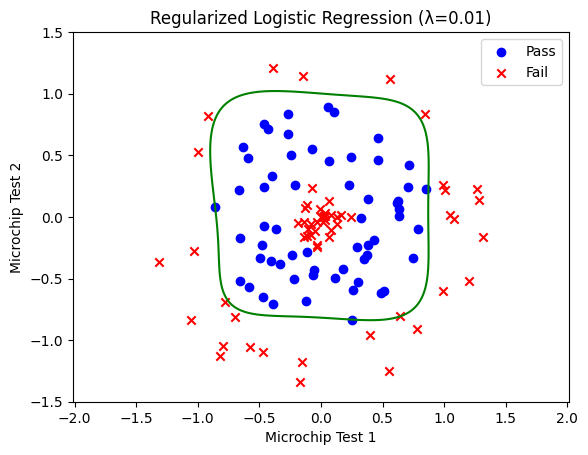

In [16]:
# Plot non-linear decision boundary using a contour grid
u = np.linspace(-1.5, 1.5, 200)
v = np.linspace(-1.5, 1.5, 200)
z_grid = np.zeros((len(u), len(v)))

for i, ui in enumerate(u):
    for j, vj in enumerate(v):
        mapped = map_feature(np.array([ui]), np.array([vj]))
        z_grid[i, j] = sigmoid(np.dot(mapped, w2) + b2)[0]

passed2 = X2_train[y2_train == 1]
failed2 = X2_train[y2_train == 0]

plt.scatter(passed2[:, 0], passed2[:, 1], marker='o', c='blue', label='Pass')
plt.scatter(failed2[:, 0], failed2[:, 1], marker='x', c='red', label='Fail')
plt.contour(u, v, z_grid.T, levels=[0.5], colors='green')
plt.xlabel('Microchip Test 1')
plt.ylabel('Microchip Test 2')
plt.title(f'Regularized Logistic Regression (λ={lambda_})')
plt.legend()
plt.axis('equal')
plt.show()

### 2.7 Evaluate Regularized Model

In [17]:
# Evaluate on training set
p2 = predict(X2_mapped, w2, b2)
accuracy2 = np.mean(p2 == y2_train) * 100
print(f"Train Accuracy (regularized): {accuracy2:.2f}%")

Train Accuracy (regularized): 72.50%


---

## Summary

| Concept | Linear Regression | Logistic Regression |
|---|---|---|
| Output | Real number | Probability (0–1) via sigmoid |
| Cost | MSE | Log-loss (binary cross-entropy) |
| Gradient formula | Same form | Same form (different $f$) |
| Decision | Continuous prediction | Threshold at 0.5 |
| Regularization | L2 on $w$ | L2 on $w$ (not $b$) |

**Key insight**: The machinery is the same — only the model $f_{w,b}$ changes. This pattern extends to neural networks, where you stack multiple logistic units.